# 03 - Visualización de Entrenamiento de Modelos

Este notebook analiza los artefactos generados por el proceso de entrenamiento y optimización de modelos para predicción cardiovascular.

Resultados incluidos:
- Evolución de trials de Optuna por modelo.
- Comparación de métricas en validación.
- Matrices de confusión por modelo.
- Curvas ROC por modelo.
- Ranking final en validación.

Criterio de interpretación:
- La selección principal se basa en ROC-AUC y F1-score en validación.

In [1]:
from pathlib import Path
import re
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
 )

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

MODEL_NAMES = {
    "LR": "Regresión Logística",
    "RF": "Random Forest",
    "XGB": "XGBoost",
    "LGBM": "LightGBM",
}

In [2]:
start_path = Path.cwd().resolve()
candidate_roots = [start_path, *start_path.parents]

PROJECT_ROOT = None
for root in candidate_roots:
    if (root / "models").exists() and (root / "notebooks").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. Abra el notebook dentro del workspace Prediccion_Cardiovascular."
    )

MODELS_DIR = PROJECT_ROOT / "models"

# Soporta ambos patrones: Experimento1 y Experimento_1
exp_pattern = re.compile(r"^Experimento_?(\d+)$")
experiments = []
for item in MODELS_DIR.iterdir() if MODELS_DIR.exists() else []:
    if item.is_dir():
        m = exp_pattern.match(item.name)
        if m:
            experiments.append((int(m.group(1)), item))

if experiments:
    latest_exp_number, latest_exp_path = sorted(experiments, key=lambda x: x[0])[-1]
    MODELS_SOURCE_DIR = latest_exp_path
    ARTIFACTS_DIR = latest_exp_path / "training_artifacts"
    source_desc = f"{latest_exp_path.name}"
else:
    latest_exp_number = None
    latest_exp_path = None
    MODELS_SOURCE_DIR = MODELS_DIR
    ARTIFACTS_DIR = MODELS_DIR / "training_artifacts"
    source_desc = "models/ (sin carpeta de experimento)"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Fuente de modelos: {source_desc}")
print(f"Carpeta de modelos: {MODELS_SOURCE_DIR}")
print(f"Carpeta de artefactos: {ARTIFACTS_DIR} {'(no encontrada)' if not ARTIFACTS_DIR.exists() else ''}")

Proyecto: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular
Fuente de modelos: Experimento4
Carpeta de modelos: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\models\Experimento4
Carpeta de artefactos: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\models\Experimento4\training_artifacts 


In [3]:
models = ["LR", "RF", "XGB", "LGBM"]

metrics_rows = []
trials_data = {}
preds_data = {}
overfit_data = {}
problematic_data = {}

for model in models:
    metrics_path = ARTIFACTS_DIR / f"val_metrics_{model}.csv"
    trials_path = ARTIFACTS_DIR / f"optuna_trials_{model}.csv"
    preds_path = ARTIFACTS_DIR / f"val_predictions_{model}.csv"
    overfit_path = ARTIFACTS_DIR / f"overfitting_diagnostics_{model}.json"
    problematic_path = ARTIFACTS_DIR / f"problematic_validation_samples_{model}.csv"

    if metrics_path.exists():
        mdf = pd.read_csv(metrics_path)
        mdf["model_name"] = mdf["model"].map(MODEL_NAMES).fillna(mdf["model"])
        metrics_rows.append(mdf)

    if trials_path.exists():
        trials_data[model] = pd.read_csv(trials_path)

    if preds_path.exists():
        preds_data[model] = pd.read_csv(preds_path)

    if overfit_path.exists():
        with open(overfit_path, "r", encoding="utf-8") as f:
            overfit_data[model] = json.load(f)

    if problematic_path.exists():
        problematic_data[model] = pd.read_csv(problematic_path)

if metrics_rows:
    metrics_df = pd.concat(metrics_rows, ignore_index=True)
    display(metrics_df)
else:
    metrics_df = pd.DataFrame()
    print(
        "No se encontraron archivos val_metrics_*.csv. "
        "Se mantendrán habilitadas únicamente las secciones con información disponible."
    )

,model,model_full_name,best_cv_composite_score,val_accuracy,val_precision,val_recall,val_f1_score,val_roc_auc,val_mcc,best_threshold,drop_uncertain_cases,uncertainty_quantile,removed_uncertain_train_samples,uncertainty_threshold_train,model_name
0,LR,Logistic Regression,0.768553,0.714008,0.676923,0.807339,0.736402,0.794853,0.437071,0.395,False,0.1,0,NaN,Regresión Logística
1,RF,Random Forest,0.773851,0.703470,0.657888,0.834862,0.735884,0.798992,0.423717,0.340,False,0.1,0,NaN,Random Forest
2,XGB,XGBoost,0.775508,0.701848,0.654838,0.840433,0.736117,0.800944,0.422214,0.335,False,0.1,0,NaN,XGBoost
3,LGBM,LightGBM,0.775606,0.706388,0.663850,0.823722,0.735195,0.800535,0.426389,0.355,False,0.1,0,NaN,LightGBM


## 1) Evolución de Optuna por Modelo

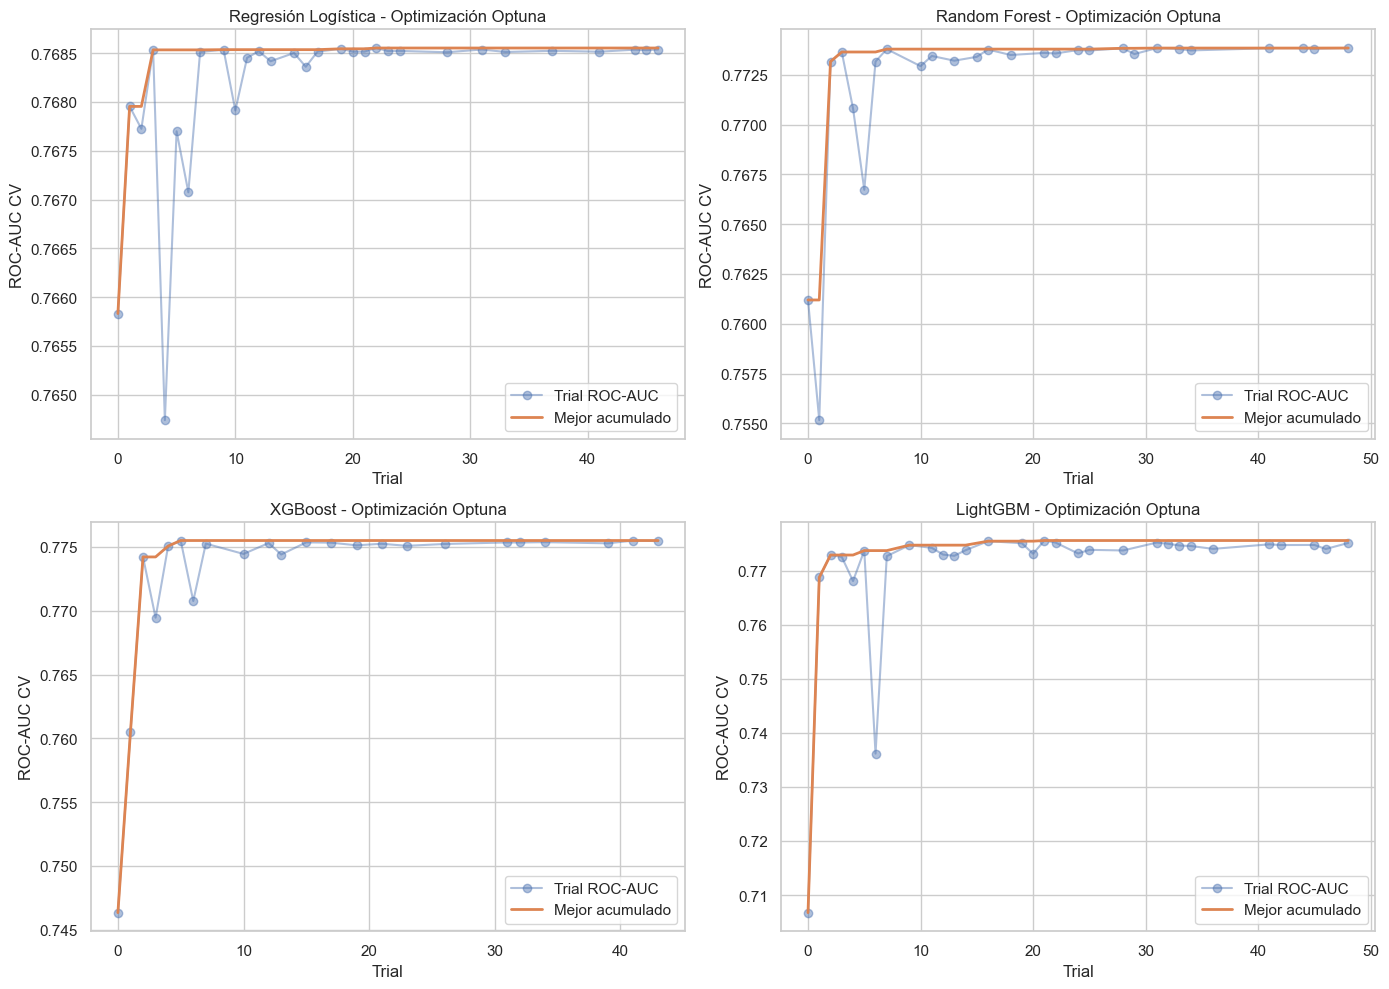

In [4]:
available_trials_models = [m for m in models if m in trials_data]

if not available_trials_models:
    print("No hay archivos de trials para graficar todavía.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, model in enumerate(models):
        ax = axes[i]
        model_label = MODEL_NAMES.get(model, model)

        if model not in trials_data:
            ax.set_title(f"{model_label} (sin datos)")
            ax.axis("off")
            continue

        df = trials_data[model].copy()
        df = df[df["state"] == "COMPLETE"].sort_values("number").reset_index(drop=True)

        if df.empty:
            ax.set_title(f"{model_label} (sin trials completos)")
            ax.axis("off")
            continue

        df["best_so_far"] = df["value"].cummax()

        ax.plot(df["number"], df["value"], marker="o", alpha=0.45, label="Trial ROC-AUC")
        ax.plot(df["number"], df["best_so_far"], linewidth=2.0, label="Mejor acumulado")
        ax.set_title(f"{model_label} - Optimización Optuna")
        ax.set_xlabel("Trial")
        ax.set_ylabel("ROC-AUC CV")
        ax.legend()

    plt.tight_layout()
    plt.show()

## 2) Comparación de Métricas de Validación

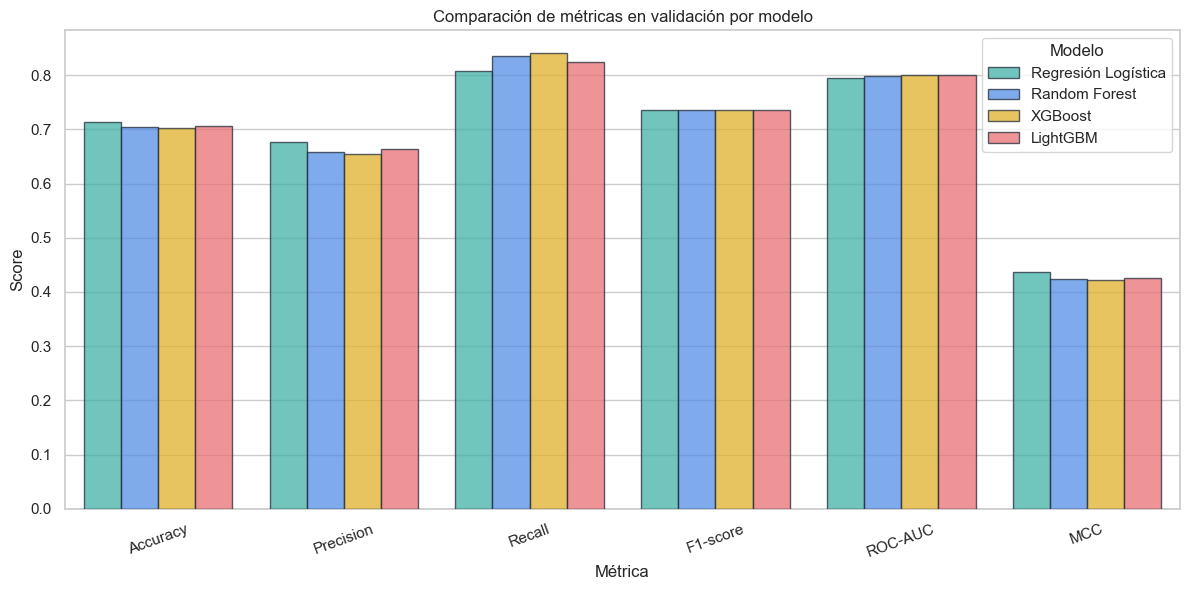

,model_name,Accuracy,Precision,Recall,F1-score,ROC-AUC,MCC
0,XGBoost,0.701848,0.654838,0.840433,0.736117,0.800944,0.422214
1,LightGBM,0.706388,0.663850,0.823722,0.735195,0.800535,0.426389
2,Random Forest,0.703470,0.657888,0.834862,0.735884,0.798992,0.423717
3,Regresión Logística,0.714008,0.676923,0.807339,0.736402,0.794853,0.437071


In [5]:
plot_columns = [
    "val_accuracy",
    "val_precision",
    "val_recall",
    "val_f1_score",
    "val_roc_auc",
    "val_mcc",
]

metric_labels = {
    "val_accuracy": "Accuracy",
    "val_precision": "Precision",
    "val_recall": "Recall",
    "val_f1_score": "F1-score",
    "val_roc_auc": "ROC-AUC",
    "val_mcc": "MCC",
}

if metrics_df.empty:
    print("No hay métricas de validación para comparar.")
else:
    available_plot_columns = [c for c in plot_columns if c in metrics_df.columns]

    if not available_plot_columns:
        print("No hay columnas de métricas de validación disponibles en metrics_df.")
    else:
        long_df = metrics_df.melt(
            id_vars=["model", "model_name"],
            value_vars=available_plot_columns,
            var_name="metric",
            value_name="score",
        )
        long_df["metric_label"] = long_df["metric"].map(metric_labels).fillna(long_df["metric"])

        custom_colors = ['#2EC4B6', '#3A86FF', '#FFBE0B', '#FF5A5F']
        hue_order = [MODEL_NAMES[m] for m in models if MODEL_NAMES.get(m, m) in long_df["model_name"].unique()]
        palette = dict(zip(hue_order, custom_colors[:len(hue_order)]))

        plt.figure(figsize=(12, 6))
        ax = sns.barplot(
            data=long_df,
            x="metric_label",
            y="score",
            hue="model_name",
            hue_order=hue_order,
            palette=palette,
            edgecolor="#1F2937",
            linewidth=1.0,
        )

        for p in ax.patches:
            p.set_alpha(0.74)
            p.set_zorder(3)

        plt.title("Comparación de métricas en validación por modelo")
        plt.xlabel("Métrica")
        plt.ylabel("Score")
        plt.xticks(rotation=20)
        plt.legend(title="Modelo")
        plt.tight_layout()
        plt.show()

        ranking_col = "val_roc_auc" if "val_roc_auc" in metrics_df.columns else available_plot_columns[0]
        table_cols = ["model_name"] + available_plot_columns
        display(
            metrics_df[table_cols]
            .rename(columns=metric_labels)
            .sort_values(metric_labels.get(ranking_col, ranking_col), ascending=False)
            .reset_index(drop=True)
        )

## 3) Matriz de Confusión por Modelo

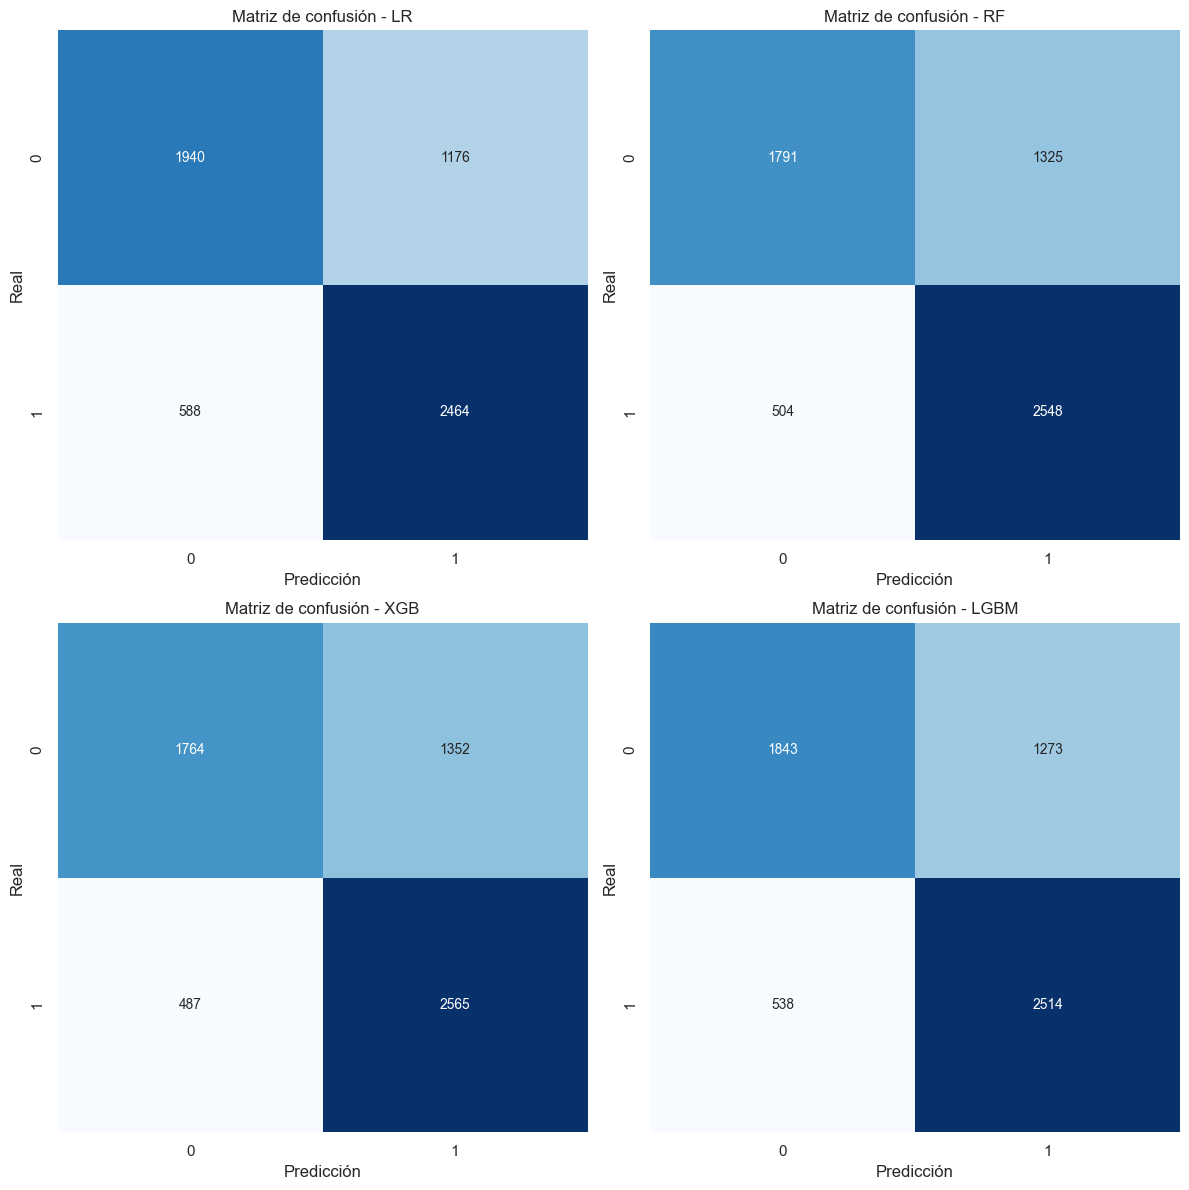

In [6]:
available_pred_models = [m for m in models if m in preds_data]

if not available_pred_models:
    print("No hay archivos de predicciones para graficar matrices de confusión.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    for i, model in enumerate(models):
        ax = axes[i]
        if model not in preds_data:
            ax.set_title(f"{model} (sin datos)")
            ax.axis("off")
            continue

        df = preds_data[model]
        cm = confusion_matrix(df["y_true"], df["y_pred"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(f"Matriz de confusión - {model}")
        ax.set_xlabel("Predicción")
        ax.set_ylabel("Real")

    plt.tight_layout()
    plt.show()

## 4) Curvas ROC por Modelo

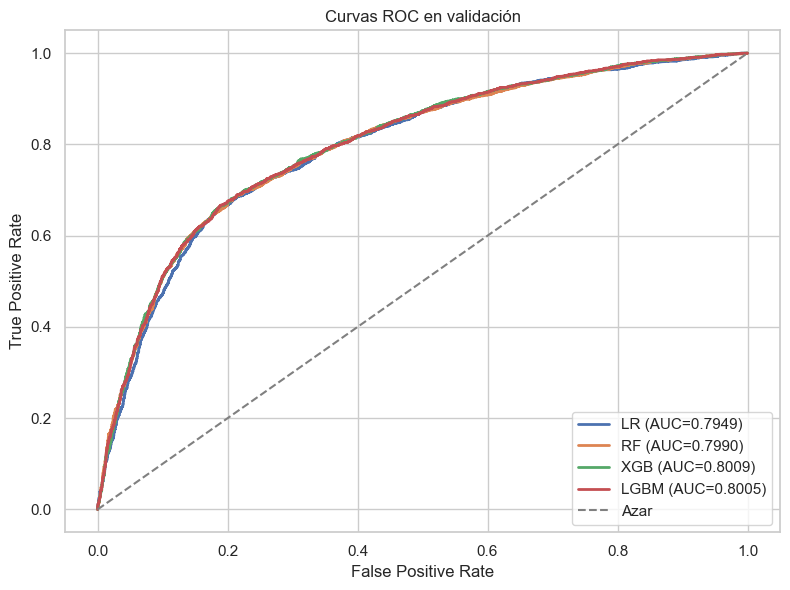

In [7]:
if not available_pred_models:
    print("No hay archivos de predicciones para graficar curvas ROC.")
else:
    plt.figure(figsize=(8, 6))

    for model in available_pred_models:
        df = preds_data[model]
        fpr, tpr, _ = roc_curve(df["y_true"], df["y_pred_proba"])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{model} (AUC={roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
    plt.title("Curvas ROC en validación")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## 5) Ranking Final de Modelos

In [8]:
if metrics_df.empty:
    print("No hay métricas para construir el ranking de validación.")
else:
    ranking_cols = [
        c for c in ["model_name", "best_cv_roc_auc", "val_roc_auc", "val_f1_score", "val_mcc"]
        if c in metrics_df.columns
    ]

    if len(ranking_cols) <= 1:
        print("No hay suficientes columnas para construir el ranking de validación.")
    else:
        sort_col = "val_roc_auc" if "val_roc_auc" in ranking_cols else ranking_cols[-1]
        ranking_df = metrics_df[ranking_cols].sort_values(sort_col, ascending=False).reset_index(drop=True)
        display(
            ranking_df.rename(
                columns={
                    "model_name": "Modelo",
                    "best_cv_roc_auc": "Mejor ROC-AUC CV",
                    "val_roc_auc": "ROC-AUC Validación",
                    "val_f1_score": "F1-score Validación",
                    "val_mcc": "MCC Validación",
                }
            )
        )

,Modelo,ROC-AUC Validación,F1-score Validación,MCC Validación
0,XGBoost,0.800944,0.736117,0.422214
1,LightGBM,0.800535,0.735195,0.426389
2,Random Forest,0.798992,0.735884,0.423717
3,Regresión Logística,0.794853,0.736402,0.437071


## 6) Diagnóstico de Sobreajuste (Train vs Validación)

Esta sección usa los archivos overfitting_diagnostics_*.json para comparar métricas de entrenamiento vs validación e identificar riesgo de sobreajuste por modelo.

,Modelo,F1 Train,F1 Validación,Gap F1,ROC-AUC Train,ROC-AUC Validación,Gap ROC-AUC,Riesgo de sobreajuste
0,XGBoost,0.740697,0.736117,0.004580,0.808666,0.800944,0.007723,bajo
1,LightGBM,0.741322,0.735195,0.006127,0.807178,0.800535,0.006643,bajo
2,Random Forest,0.737915,0.735884,0.002030,0.804957,0.798992,0.005965,bajo
3,Regresión Logística,0.733917,0.736402,-0.002485,0.792517,0.794853,-0.002336,bajo


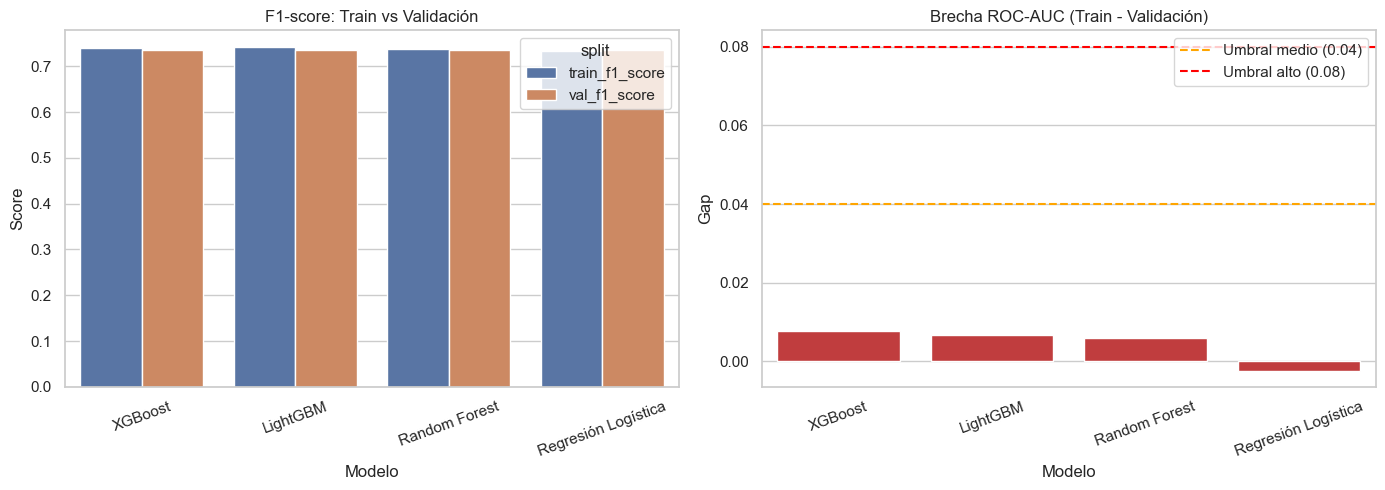

In [9]:
available_overfit_models = [m for m in models if m in overfit_data]

if not available_overfit_models:
    print("No hay archivos overfitting_diagnostics_*.json para visualizar.")
else:
    rows = []
    for model in available_overfit_models:
        d = overfit_data[model]
        rows.append({
            "model": model,
            "model_name": MODEL_NAMES.get(model, model),
            "train_f1_score": d.get("train_f1_score"),
            "val_f1_score": d.get("val_f1_score"),
            "gap_f1_score": d.get("gap_f1_score"),
            "train_roc_auc": d.get("train_roc_auc"),
            "val_roc_auc": d.get("val_roc_auc"),
            "gap_roc_auc": d.get("gap_roc_auc"),
            "overfitting_risk": d.get("overfitting_risk", "desconocido"),
        })

    overfit_df = pd.DataFrame(rows).sort_values("gap_roc_auc", ascending=False).reset_index(drop=True)
    display(
        overfit_df[[
            "model_name",
            "train_f1_score",
            "val_f1_score",
            "gap_f1_score",
            "train_roc_auc",
            "val_roc_auc",
            "gap_roc_auc",
            "overfitting_risk",
        ]].rename(columns={
            "model_name": "Modelo",
            "train_f1_score": "F1 Train",
            "val_f1_score": "F1 Validación",
            "gap_f1_score": "Gap F1",
            "train_roc_auc": "ROC-AUC Train",
            "val_roc_auc": "ROC-AUC Validación",
            "gap_roc_auc": "Gap ROC-AUC",
            "overfitting_risk": "Riesgo de sobreajuste",
        })
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    f1_long = overfit_df[["model_name", "train_f1_score", "val_f1_score"]].melt(
        id_vars="model_name",
        var_name="split",
        value_name="score",
    )
    sns.barplot(data=f1_long, x="model_name", y="score", hue="split", ax=axes[0])
    axes[0].set_title("F1-score: Train vs Validación")
    axes[0].set_xlabel("Modelo")
    axes[0].set_ylabel("Score")
    axes[0].tick_params(axis="x", rotation=20)

    sns.barplot(data=overfit_df, x="model_name", y="gap_roc_auc", ax=axes[1], color="#d62728")
    axes[1].set_title("Brecha ROC-AUC (Train - Validación)")
    axes[1].set_xlabel("Modelo")
    axes[1].set_ylabel("Gap")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].axhline(0.04, color="orange", linestyle="--", linewidth=1.5, label="Umbral medio (0.04)")
    axes[1].axhline(0.08, color="red", linestyle="--", linewidth=1.5, label="Umbral alto (0.08)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 7) Muestras Problemáticas en Validación

Esta sección resume los casos conflictivos detectados en problematic_validation_samples_*.csv, incluyendo errores de alta confianza y casos inciertos cerca del umbral de decisión.

,model,Modelo,Total de muestras problemáticas,Errores de alta confianza,Casos inciertos
0,LR,Regresión Logística,689,72,617
2,XGB,XGBoost,684,67,617
3,LGBM,LightGBM,683,66,617
1,RF,Random Forest,680,63,617


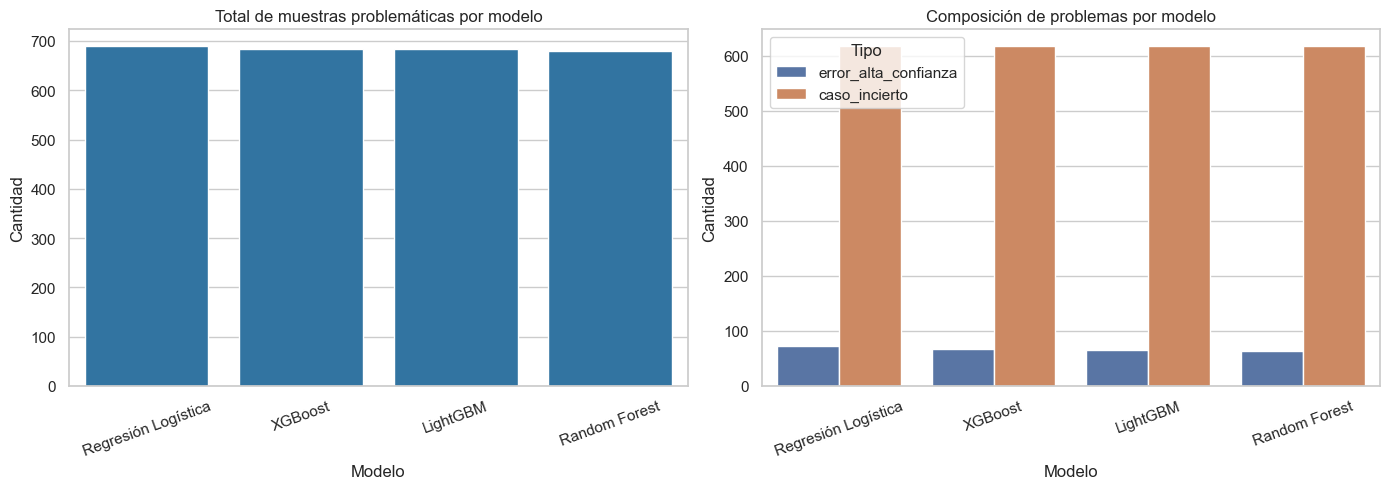

,model_name,row_id_val,problem_type,problem_score,y_true,y_pred,y_pred_proba,pred_confidence,uncertainty
0,Random Forest,1479,caso_incierto,0.999943,1,1,0.500028,0.500028,0.000028
1,XGBoost,642,caso_incierto,0.999922,1,1,0.500039,0.500039,0.000039
2,Random Forest,1193,caso_incierto,0.999831,0,1,0.499916,0.499916,0.000084
3,Regresión Logística,4492,caso_incierto,0.999820,0,1,0.500090,0.500090,0.000090
4,Regresión Logística,1951,caso_incierto,0.999758,1,1,0.499879,0.499879,0.000121
5,XGBoost,3381,caso_incierto,0.999755,0,1,0.499878,0.499878,0.000122
6,Regresión Logística,651,caso_incierto,0.999754,0,1,0.499877,0.499877,0.000123
7,Regresión Logística,5443,caso_incierto,0.999700,1,1,0.499850,0.499850,0.000150
8,Regresión Logística,1839,caso_incierto,0.999673,0,1,0.499836,0.499836,0.000164
9,Random Forest,1092,caso_incierto,0.999632,0,1,0.499816,0.499816,0.000184


In [10]:
available_problem_models = [m for m in models if m in problematic_data]

if not available_problem_models:
    print("No hay archivos problematic_validation_samples_*.csv para visualizar.")
else:
    summary_rows = []
    for model in available_problem_models:
        pdf = problematic_data[model].copy()
        if pdf.empty:
            summary_rows.append({
                "model": model,
                "model_name": MODEL_NAMES.get(model, model),
                "total_problematic": 0,
                "error_alta_confianza": 0,
                "caso_incierto": 0,
            })
            continue

        type_counts = pdf["problem_type"].value_counts()
        summary_rows.append({
            "model": model,
            "model_name": MODEL_NAMES.get(model, model),
            "total_problematic": len(pdf),
            "error_alta_confianza": int(type_counts.get("error_alta_confianza", 0)),
            "caso_incierto": int(type_counts.get("caso_incierto", 0)),
        })

    problem_summary_df = pd.DataFrame(summary_rows).sort_values("total_problematic", ascending=False)
    display(
        problem_summary_df.rename(columns={
            "model_name": "Modelo",
            "total_problematic": "Total de muestras problemáticas",
            "error_alta_confianza": "Errores de alta confianza",
            "caso_incierto": "Casos inciertos",
        })
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=problem_summary_df, x="model_name", y="total_problematic", ax=axes[0], color="#1f77b4")
    axes[0].set_title("Total de muestras problemáticas por modelo")
    axes[0].set_xlabel("Modelo")
    axes[0].set_ylabel("Cantidad")
    axes[0].tick_params(axis="x", rotation=20)

    long_problem = problem_summary_df.melt(
        id_vars=["model_name"],
        value_vars=["error_alta_confianza", "caso_incierto"],
        var_name="tipo",
        value_name="cantidad",
    )
    sns.barplot(data=long_problem, x="model_name", y="cantidad", hue="tipo", ax=axes[1])
    axes[1].set_title("Composición de problemas por modelo")
    axes[1].set_xlabel("Modelo")
    axes[1].set_ylabel("Cantidad")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].legend(title="Tipo")

    plt.tight_layout()
    plt.show()

    top_rows = []
    for model in available_problem_models:
        pdf = problematic_data[model].copy()
        if pdf.empty or "problem_score" not in pdf.columns:
            continue
        pdf["model_name"] = MODEL_NAMES.get(model, model)
        top_rows.append(pdf.sort_values("problem_score", ascending=False).head(10))

    if top_rows:
        top_problematic_df = pd.concat(top_rows, ignore_index=True)
        cols = [c for c in ["model_name", "row_id_val", "problem_type", "problem_score", "y_true", "y_pred", "y_pred_proba", "pred_confidence", "uncertainty"] if c in top_problematic_df.columns]
        display(
            top_problematic_df[cols]
            .sort_values(["problem_score"], ascending=False)
            .reset_index(drop=True)
        )